In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

In [ ]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab Notebooks')
print(f"Current working directory changed to: {os.getcwd()}")

Current working directory changed to: /content/drive/MyDrive/Colab Notebooks


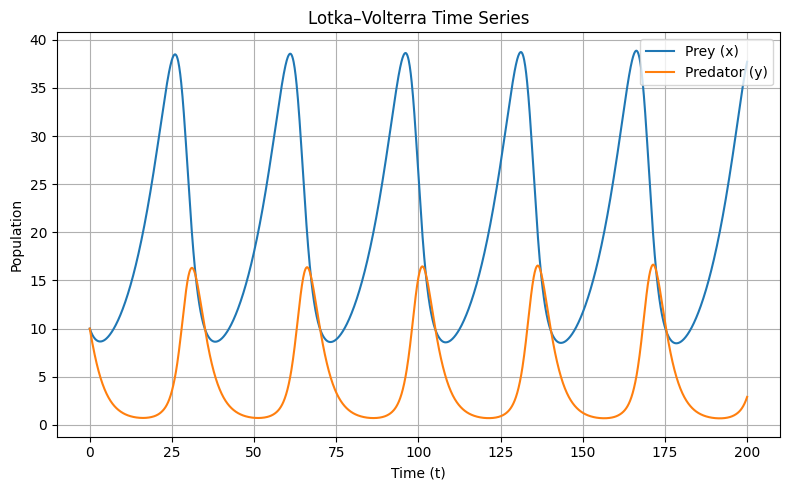

In [ ]:
# Load CSV
df = pd.read_csv("lotka_volterra_data.csv")

# Extract columns
t = df["t"]
x = df["x"]
y = df["y"]

# Plot
plt.figure(figsize=(8,5))
plt.plot(t, x, label="Prey (x)")
plt.plot(t, y, label="Predator (y)")

plt.xlabel("Time (t)")
plt.ylabel("Population")
plt.title("Lotka–Volterra Time Series")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import time

In [ ]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
# =========================
# 1. Load data
# =========================
data = pd.read_csv("lotka_volterra_data.csv")

t_np = data["t"].values.astype(np.float32)
x_np = data["x"].values.astype(np.float32)
y_np = data["y"].values.astype(np.float32)


# Convert to torch tensors
t = torch.tensor(t_np).view(-1, 1)   # shape (N, 1)
x = torch.tensor(x_np).view(-1, 1)       # shape (N, 1)
y = torch.tensor(y_np).view(-1, 1)       # shape (N, 1)

# Put everything on device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t = t.to(device)
x = x.to(device)
y = y.to(device)

# =========================
# 2. Define PINN model
# =========================

class VanillaPINN(nn.Module):
    def __init__(self, hidden_dim=64, n_hidden=3):
        super().__init__()
        layers = []
        in_dim = 1
        out_dim = 2  # x_hat, y_hat

        # Input layer
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.Tanh())

        # Hidden layers
        for _ in range(n_hidden - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())

        # Output layer
        layers.append(nn.Linear(hidden_dim, out_dim))

        self.net = nn.Sequential(*layers)

        # Trainable parameters: alpha, beta, gamma, delta
        # Start with some positive initial guesses
        self.alpha = nn.Parameter(torch.tensor(1.0, dtype=torch.float32))
        self.beta  = nn.Parameter(torch.tensor(1.0, dtype=torch.float32))
        self.gamma = nn.Parameter(torch.tensor(1.0, dtype=torch.float32))
        self.delta = nn.Parameter(torch.tensor(1.0, dtype=torch.float32))

    def forward(self, t):
        """Return x_hat(t), y_hat(t)."""
        return self.net(t)  # shape (N, 2)

    def ode_residuals(self, t):
        """
        Compute the ODE residuals:
        f1 = dx/dt - ( alpha*x - beta*x*y )
        f2 = dy/dt - ( -gamma*y + delta*x*y )
        """
        t = t.clone().detach().requires_grad_(True)
        start_time = time.time()
        xy_hat = self.forward(t)
        end_time = time.time()
        net_computation = end_time - start_time

        x_hat = xy_hat[:, 0:1]  # (N, 1)
        y_hat = xy_hat[:, 1:2]  # (N, 1)

        # Autograd for dx/dt, dy/dt
        dxdt = torch.autograd.grad(
            x_hat,
            t,
            grad_outputs=torch.ones_like(x_hat),
            create_graph=True,
            retain_graph=True
        )[0]

        dydt = torch.autograd.grad(
            y_hat,
            t,
            grad_outputs=torch.ones_like(y_hat),
            create_graph=True,
            retain_graph=True
        )[0]

        # Lotka–Volterra RHS
        alpha = self.alpha
        beta  = self.beta
        gamma = self.gamma
        delta = self.delta

        f1 = dxdt - (alpha * x_hat - beta * x_hat * y_hat)
        f2 = dydt - (-gamma * y_hat + delta * x_hat * y_hat)

        return f1, f2, x_hat, y_hat, net_computation

# Instantiate model
model = VanillaPINN(hidden_dim=64, n_hidden=3).to(device)

# =========================
# 3. Loss & optimizer
# =========================
mse_loss = nn.MSELoss()

# Optimize both network weights and parameters
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Trade-off between data and physics loss
lambda_data = 1.0
lambda_phys = 1.0

# =========================
# 4. Training loop
# =========================
n_epochs = 10000

# === History containers ===
pinn_history = {
    "epoch": [],
    "loss_total": [],
    "loss_data": [],
    "loss_phys": [],
    "alpha": [],
    "beta": [],
    "gamma": [],
    "delta": [],
    "net_time": [],
    "backward_time": [],
    "optimizer_time": []
}

for epoch in range(1, n_epochs + 1):
    model.train()
    optimizer.zero_grad()

    # Physics residuals & predictions
    f1, f2, x_hat, y_hat, net_computation = model.ode_residuals(t)

    # Data mismatch (x_hat,y_hat vs data)
    loss_data = mse_loss(x_hat, x) + mse_loss(y_hat, y)

    # Physics loss (ODE residuals ~ 0)
    zero = torch.zeros_like(f1)
    loss_phys = mse_loss(f1, zero) + mse_loss(f2, zero)

    # Total loss
    loss = lambda_data * loss_data + lambda_phys * loss_phys

    start_time = time.time()
    loss.backward()
    end_time = time.time()
    backward_computation = end_time - start_time

    start_time = time.time()
    optimizer.step()
    end_time = time.time()
    optimizer_computation = end_time - start_time

    if epoch % 1000 == 0:
        print(
            f"Epoch {epoch:6d} | "
            f"Total: {loss.item():.4e} | "
            f"Data: {loss_data.item():.4e} | "
            f"Phys: {loss_phys.item():.4e} | "
            f"alpha: {model.alpha.item():.4f}, "
            f"beta: {model.beta.item():.4f}, "
            f"gamma: {model.gamma.item():.4f}, "
            f"delta: {model.delta.item():.4f}"
        )

    # Log history
    pinn_history["epoch"].append(epoch)
    pinn_history["loss_total"].append(loss.item())
    pinn_history["loss_data"].append(loss_data.item())
    pinn_history["loss_phys"].append(loss_phys.item())
    pinn_history["alpha"].append(model.alpha.item())
    pinn_history["beta"].append(model.beta.item())
    pinn_history["gamma"].append(model.gamma.item())
    pinn_history["delta"].append(model.delta.item())
    pinn_history["net_time"].append(net_computation)
    pinn_history["backward_time"].append(backward_computation)
    pinn_history["optimizer_time"].append(optimizer_computation)

# =========================
# 5. Print final estimates
# =========================
print("\nEstimated parameters:")
print(f"alpha ≈ {model.alpha.item():.6f}")
print(f"beta  ≈ {model.beta.item():.6f}")
print(f"gamma ≈ {model.gamma.item():.6f}")
print(f"delta ≈ {model.delta.item():.6f}")


history_df = pd.DataFrame(pinn_history)
history_df.to_csv('pinn_training_history.csv', index=False)
print("Training history saved to 'pinn_training_history.csv'")

Epoch   1000 | Total: 1.3989e+02 | Data: 1.3915e+02 | Phys: 7.3956e-01 | alpha: 0.4007, beta: 1.4998, gamma: 1.5561, delta: 0.2386
Epoch   2000 | Total: 1.3627e+02 | Data: 1.3622e+02 | Phys: 4.8744e-02 | alpha: 0.7205, beta: 1.1955, gamma: 1.6583, delta: 0.0829
Epoch   3000 | Total: 1.2002e+02 | Data: 1.1956e+02 | Phys: 4.6579e-01 | alpha: 1.1308, beta: 0.2448, gamma: 1.2589, delta: 0.0628
Epoch   4000 | Total: 1.1962e+02 | Data: 1.1949e+02 | Phys: 1.3232e-01 | alpha: 1.0987, beta: 0.2342, gamma: 0.5457, delta: 0.0272
Epoch   5000 | Total: 7.1180e+01 | Data: 7.0582e+01 | Phys: 5.9816e-01 | alpha: 0.8569, beta: 0.1757, gamma: 0.0758, delta: 0.0038
Epoch   6000 | Total: 3.0485e+01 | Data: 3.0249e+01 | Phys: 2.3686e-01 | alpha: 0.1041, beta: 0.0211, gamma: 0.3280, delta: 0.0160
Epoch   7000 | Total: 2.3992e+01 | Data: 2.3930e+01 | Phys: 6.2762e-02 | alpha: 0.0973, beta: 0.0201, gamma: 0.3867, delta: 0.0192
Epoch   8000 | Total: 1.6984e+01 | Data: 1.6869e+01 | Phys: 1.1460e-01 | alpha: 0.0

In [ ]:
from ast import Del
from torch.autograd import forward_ad
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

data = pd.read_csv("lotka_volterra_data.csv")

t_np = data["t"].values.astype(np.float32)
x_np = data["x"].values.astype(np.float32)
y_np = data["y"].values.astype(np.float32)


# Convert to torch tensors
t = torch.tensor(t_np).view(-1, 1)   # shape (N, 1)
x = torch.tensor(x_np).view(-1, 1)       # shape (N, 1)
y = torch.tensor(y_np).view(-1, 1)       # shape (N, 1)

# Put everything on device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t = t.to(device)
x = x.to(device)
y = y.to(device)

class FullNewtonLayerKKT(nn.Module):

    def __init__(self, K = 10, tol = 1e-9, max_backtrack = 10, c = 1e-4):
        super().__init__()
        self.K = K
        self.tol = tol
        self.max_backtrack = max_backtrack
        self.c = c
        self.Delt = 1e-3


    def forward(self, t, pred_hat, pred_hat_d, dxdt, dydt, alpha, beta, gamma, delta):
        device = t.device
        bsz = x.size(0)

        #initial guess
        lambda1 = pred_hat[:, 2:3]
        lambda2 = pred_hat[:, 3:4]
        dxdt = dxdt
        dydt = dydt

        x_hat = pred_hat[:, 0:1]
        y_hat = pred_hat[:, 1:2]
        x_hat_d = pred_hat_d[:, 0:1]
        y_hat_d = pred_hat_d[:, 1:2]

        for _ in range(self.K):
            # Residuals
            f1 = 2*(x_hat_d - self.Delt*dxdt - x_hat)*(-self.Delt) + lambda1 + alpha*self.Delt*lambda1 + beta*lambda1*(y_hat_d - self.Delt*dydt)*(-self.Delt) - delta*lambda2*(y_hat_d - self.Delt*dydt)*(-self.Delt)
            f2 = 2*(y_hat_d - self.Delt*dydt - y_hat)*(-self.Delt) + lambda2 - gamma*self.Delt*lambda2 + beta*lambda1*(x_hat_d - self.Delt*dxdt)*(-self.Delt) - delta*lambda2*(x_hat_d - self.Delt*dxdt)*(-self.Delt)
            f3 = dxdt - alpha*(x_hat_d - self.Delt*dxdt) + beta*(x_hat_d - self.Delt*dxdt)*(y_hat_d - self.Delt*dydt)
            f4 = dydt + gamma*(y_hat_d - self.Delt*dydt) - delta*(x_hat_d - self.Delt*dxdt)*(y_hat_d - self.Delt*dydt)

            F = torch.cat([f1, f2, f3, f4], dim=1)
            maxF = F.abs().max()
            if maxF < self.tol:
                break

            J = torch.zeros(bsz, 4, 4, device=device)

            J11 = 2*(self.Delt)**2
            J21 = (beta*(self.Delt**2)*lambda1 - delta*(self.Delt**2)*lambda2).squeeze(-1)
            J22 = 2*(self.Delt)**2
            J31 = (1 + alpha*self.Delt - beta*self.Delt*(y_hat_d - self.Delt*dydt)).squeeze(-1)
            J32 = (-beta*self.Delt*(x_hat_d - self.Delt*dxdt)).squeeze(-1)
            J41 = (delta*self.Delt*(y_hat_d - self.Delt*dydt)).squeeze(-1)
            J42 = (1 - gamma*self.Delt + delta*self.Delt*(x_hat_d - self.Delt*dxdt)).squeeze(-1)

            J[:, 0, 0] = J11
            J[:, 0, 1] = J21
            J[:, 0, 2] = J31
            J[:, 0, 3] = J41
            J[:, 1, 0] = J21
            J[:, 1, 1] = J22
            J[:, 1, 2] = J32
            J[:, 1, 3] = J42
            J[:, 2, 0] = J31
            J[:, 2, 1] = J32
            J[:, 2, 2] = 0
            J[:, 2, 3] = 0
            J[:, 3, 0] = J41
            J[:, 3, 1] = J42
            J[:, 3, 2] = 0
            J[:, 3, 3] = 0

            # regularized normal equations
            JT = J.transpose(-2,-1)
            JTJ = JT @ J
            eps = 1e-6
            I = torch.eye(JTJ.size(-1), device=device)
            A = JTJ + eps * I
            b = JT @ (-F.unsqueeze(-1))
            delta_newton = torch.linalg.solve(A, b).squeeze(-1)

            alpha_step = 1.0
            for _ in range(self.max_backtrack):
                dxdt_new = dxdt + alpha_step * delta_newton[:, 0:1]
                dydt_new = dydt + alpha_step * delta_newton[:, 1:2]
                lambda1_new = lambda1 + alpha_step * delta_newton[:, 2:3]
                lambda2_new = lambda2 + alpha_step * delta_newton[:, 3:4]

                # compute residuals
                f1_new = (2 * (x_hat_d - self.Delt * dxdt_new - x_hat) * (-self.Delt)
                            + lambda1_new
                            + alpha * self.Delt * lambda1_new
                            + beta  * lambda1_new * (y_hat_d - self.Delt * dydt_new) * (-self.Delt)
                            - delta * lambda2_new * (y_hat_d - self.Delt * dydt_new) * (-self.Delt)
                        )

                f2_new = (2 * (y_hat_d - self.Delt * dydt_new - y_hat) * (-self.Delt)
                            + lambda2_new
                            - gamma * self.Delt * lambda2_new
                            + beta  * lambda1_new * (x_hat_d - self.Delt * dydt_new) * (-self.Delt)
                            - delta * lambda2_new * (x_hat_d - self.Delt * dydt_new) * (-self.Delt)
                        )

                f3_new = (dxdt_new - alpha * (x_hat_d - self.Delt * dxdt_new)
                            + beta  * (x_hat_d - self.Delt * dxdt_new)
                            * (y_hat_d - self.Delt * dydt_new)
                        )

                f4_new = (dydt_new + gamma * (y_hat_d - self.Delt * dydt_new)
                            - delta * (x_hat_d - self.Delt * dxdt_new)
                            * (y_hat_d - self.Delt * dydt_new)
                        )

                F_new = torch.cat([f1_new, f2_new, f3_new, f4_new], dim=1)
                maxF_new = F_new.abs().max()
                if maxF_new < (1- self.c*alpha_step)*maxF:
                    break
                alpha_step = 0.5

            # dxdt_new = dxdt + alpha_step * delta_newton[:, 0:1]
            # dydt_new = dydt + alpha_step * delta_newton[:, 1:2]
            # lambda1_new = lambda1 + alpha_step * delta_newton[:, 2:3]
            # lambda2_new = lambda2 + alpha_step * delta_newton[:, 3:4]

            # # compute residuals
            # f1_new = (2 * (x_hat_d - self.Delt * dxdt_new - x_hat) * (-self.Delt)
            #             + lambda1_new
            #             + alpha * self.Delt * lambda1_new
            #             + beta  * lambda1_new * (y_hat_d - self.Delt * dydt_new) * (-self.Delt)
            #             - delta * lambda2_new * (y_hat_d - self.Delt * dydt_new) * (-self.Delt)
            #         )

            # f2_new = (2 * (y_hat_d - self.Delt * dydt_new - y_hat) * (-self.Delt)
            #             + lambda2_new
            #             - gamma * self.Delt * lambda2_new
            #             + beta  * lambda1_new * (x_hat_d - self.Delt * dydt_new) * (-self.Delt)
            #             - delta * lambda2_new * (x_hat_d - self.Delt * dydt_new) * (-self.Delt)
            #         )

            # f3_new = (dxdt_new - alpha * (x_hat_d - self.Delt * dxdt_new)
            #             + beta  * (x_hat_d - self.Delt * dxdt_new)
            #             * (y_hat_d - self.Delt * dydt_new)
            #         )

            # f4_new = (dydt_new + gamma * (y_hat_d - self.Delt * dydt_new)
            #             - delta * (x_hat_d - self.Delt * dxdt_new)
            #             * (y_hat_d - self.Delt * dydt_new)
            #         )

            # F_new = torch.cat([f1_new, f2_new, f3_new, f4_new], dim=1)

            dxdt = dxdt_new
            dydt = dydt_new
            lambda1 = lambda1_new
            lambda2 = lambda2_new

        return dxdt, dydt

    def TaylorReconstruction(self, t, dxdt, dydt, pred_hat_d):
        x_hat_d = pred_hat_d[:, 0:1]
        y_hat_d = pred_hat_d[:, 1:2]
        x_tilde = x_hat_d - self.Delt*dxdt
        y_tilde = y_hat_d - self.Delt*dydt

        return torch.cat([x_tilde, y_tilde], dim=1)



class DAEHN(nn.Module):

    def __init__(self, hidden_dim=64, n_hidden=3):
        super().__init__()
        layers = []
        in_dim = 1
        out_dim = 4  # x_hat, y_hat, lambda1_hat, lambda2_hat
        self.Delt = 1e-3

        # Input layer
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.Tanh())

        # Hidden layers
        for _ in range(n_hidden - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())

        # Output layer
        layers.append(nn.Linear(hidden_dim, out_dim))

        self.net = nn.Sequential(*layers)

        # Trainable parameters: alpha, beta, gamma, delta
        # Start with some positive initial guesses
        self.alpha = nn.Parameter(torch.tensor(1.0, dtype=torch.float32))
        self.beta  = nn.Parameter(torch.tensor(1.0, dtype=torch.float32))
        self.gamma = nn.Parameter(torch.tensor(1.0, dtype=torch.float32))
        self.delta = nn.Parameter(torch.tensor(1.0, dtype=torch.float32))

        self.projection = FullNewtonLayerKKT()

    def forward(self, t):
        t = t.clone().detach().requires_grad_(True)

        start_time = time.time()
        pred_hat = self.net(t)
        end_time = time.time()
        net_computation = end_time - start_time

        x_hat = pred_hat[:, 0:1]  # Extract x_hat
        y_hat = pred_hat[:, 1:2]  # Extract y_hat

        # Autograd for dx/dt, dy/dt
        dxdt_autograd = torch.autograd.grad(
            x_hat,
            t,
            grad_outputs=torch.ones_like(x_hat),
            create_graph=True,
            retain_graph=True
        )[0]

        dydt_autograd = torch.autograd.grad(
            y_hat,
            t,
            grad_outputs=torch.ones_like(y_hat),
            create_graph=True,
            retain_graph=True
        )[0]

        t_d = t - self.Delt
        pred_hat_d = self.net(t_d)

        start_time = time.time()
        dxdt, dydt = self.projection(t, pred_hat, pred_hat_d, dxdt_autograd, dydt_autograd, self.alpha, self.beta, self.gamma, self.delta)
        end_time = time.time()
        projection_computation = end_time - start_time

        tilde_prediction = self.projection.TaylorReconstruction(t, dxdt, dydt, pred_hat_d)

        x_tilde = tilde_prediction[:, 0:1]
        y_tilde = tilde_prediction[:, 1:2]
        mse_before_after_projection  = torch.mean((y_hat - y_tilde)**2).item()

        f1r = dxdt - (self.alpha * x_tilde - self.beta * x_tilde * y_tilde)
        f2r = dydt - (-self.gamma * y_tilde + self.delta * x_tilde * y_tilde)
        residue = torch.mean(torch.cat([f1r, f2r], dim=1).abs()).item() # Removed dim=0 to get a scalar


        return tilde_prediction, residue, dxdt_autograd, dydt_autograd, dxdt, dydt, net_computation, projection_computation, mse_before_after_projection

def mse_mape(Yh, Y):
    mse  = torch.mean((Yh - Y)**2).item()
    mape = torch.mean((Yh - Y).abs()/Y.abs().clamp_min(1e-12)).item()
    return mse, mape

# Instantiate model
model = DAEHN(hidden_dim=64, n_hidden=3).to(device)

mse_loss = nn.MSELoss()

# Optimize both network weights and parameters
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Trade-off between data and physics loss
lambda_data = 1.0
lambda_phys = 1.0

n_epochs = 50000

# === History containers ===
history = {
    "epoch": [],
    "loss_total": [],
    "loss_data": [],
    "loss_grad": [],
    "residue": [],
    "alpha": [],
    "beta": [],
    "gamma": [],
    "delta": [],
    "net_time": [],
    "proj_time": [],
    "backward_time": [],
    "optimizer_time": [],
    "projection_consistency": []
}

for epoch in range(1, n_epochs + 1):
    model.train()
    optimizer.zero_grad()

    tilde_prediction, residue, dxdt_autograd, dydt_autograd, dxdt, dydt, net_computation, projection_computation, mse_before_after_projection = model(t)

    x_tilde = tilde_prediction[:, 0:1]
    y_tilde = tilde_prediction[:, 1:2]
    # Data mismatch (x_hat,y_hat vs data)
    loss_data = mse_loss(x_tilde, x) + mse_loss(y_tilde, y)

    # Gradient Loss
    loss_grad = mse_loss(dxdt_autograd, dxdt) + mse_loss(dydt_autograd, dydt)

    # Total loss
    loss = lambda_data * loss_data + lambda_phys * loss_grad

    start_time = time.time()
    loss.backward()
    end_time = time.time()
    backward_computation = end_time - start_time

    start_time = time.time()
    optimizer.step()
    end_time = time.time()
    optimizer_computation = end_time - start_time

    if epoch % 1000 == 0:
        print(
            f"Epoch {epoch:6d} | "
            f"Total: {loss.item():.4e} | "
            f"Data: {loss_data.item():.4e} | "
            f"Grad: {loss_grad.item():.4e} | "
            f"alpha: {model.alpha.item():.4f}, "
            f"beta: {model.beta.item():.4f}, "
            f"gamma: {model.gamma.item():.4f}, "
            f"delta: {model.delta.item():.4f}, "
            f"Residue: {residue:.4e}"
        )

    # Log history
    history["epoch"].append(epoch)
    history["loss_total"].append(loss.item())
    history["loss_data"].append(loss_data.item())
    history["loss_grad"].append(loss_grad.item())
    history["residue"].append(residue)
    history["alpha"].append(model.alpha.item())
    history["beta"].append(model.beta.item())
    history["gamma"].append(model.gamma.item())
    history["delta"].append(model.delta.item())
    history["net_time"].append(net_computation)
    history["proj_time"].append(projection_computation)
    history["backward_time"].append(backward_computation)
    history["optimizer_time"].append(optimizer_computation)
    history["projection_consistency"].append(mse_before_after_projection)

# import pandas as pd

history_df = pd.DataFrame(history)
history_df.to_csv('daehn_training_history.csv', index=False)
print("Training history saved to 'daehn_training_history.csv'")

# =========================
# 5. Print final estimates
# =========================
print("\nEstimated parameters:")
print(f"alpha \u2248 {model.alpha.item():.6f}")
print(f"beta  \u2248 {model.beta.item():.6f}")
print(f"gamma \u2248 {model.gamma.item():.6f}")
print(f"delta \u2248 {model.delta.item():.6f}")

Epoch   1000 | Total: 1.3984e+02 | Data: 1.3913e+02 | Grad: 7.1107e-01 | alpha: 0.4041, beta: 1.4985, gamma: 1.5544, delta: 0.2337, Residue: 8.2048e-08
Epoch   2000 | Total: 1.3608e+02 | Data: 1.3603e+02 | Grad: 5.0474e-02 | alpha: 0.7360, beta: 1.1765, gamma: 1.6524, delta: 0.0826, Residue: 1.8391e-07
Epoch   3000 | Total: 1.2001e+02 | Data: 1.1955e+02 | Grad: 4.5208e-01 | alpha: 1.1329, beta: 0.2451, gamma: 1.2314, delta: 0.0614, Residue: 2.7185e-07
Epoch   4000 | Total: 1.1962e+02 | Data: 1.1949e+02 | Grad: 1.2761e-01 | alpha: 1.1002, beta: 0.2345, gamma: 0.5312, delta: 0.0265, Residue: 2.8702e-07
Epoch   5000 | Total: 1.1845e+02 | Data: 1.1810e+02 | Grad: 3.4671e-01 | alpha: 1.0394, beta: 0.2182, gamma: 0.2004, delta: 0.0100, Residue: 2.8842e-07
Epoch   6000 | Total: 4.0868e+01 | Data: 4.0372e+01 | Grad: 4.9561e-01 | alpha: 0.1216, beta: 0.0241, gamma: 0.2505, delta: 0.0120, Residue: 3.6743e-08


KeyboardInterrupt: 

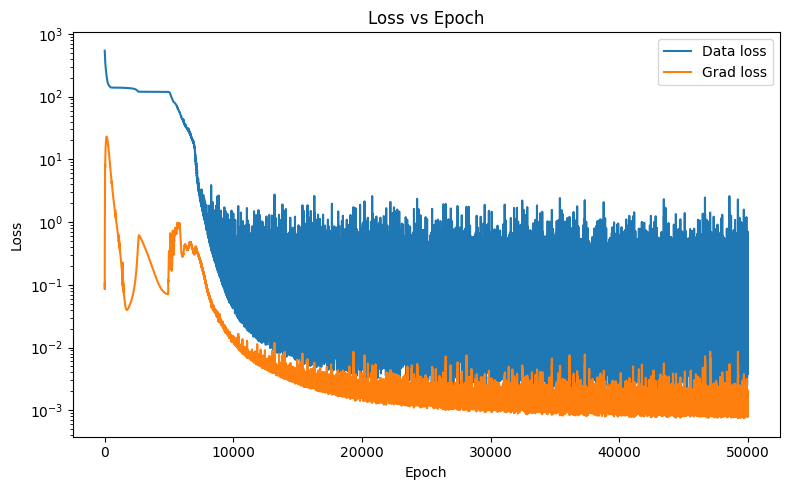

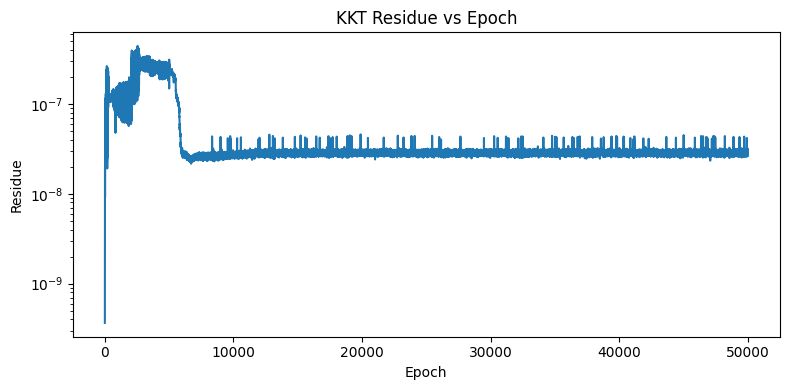

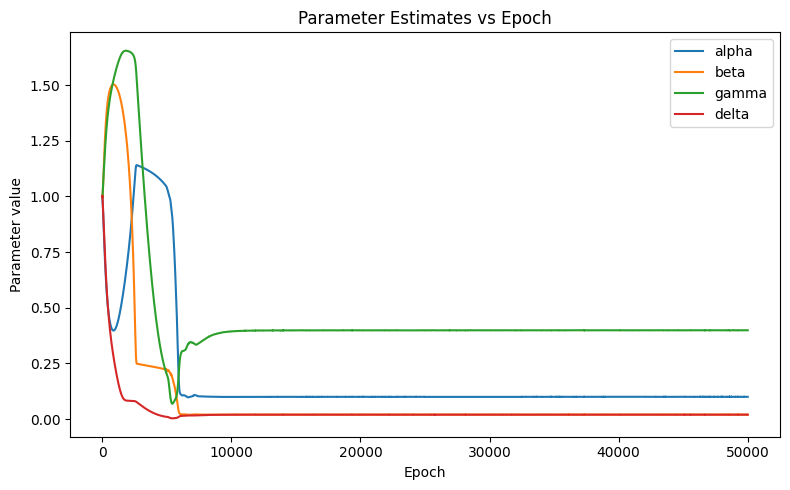

In [ ]:
import matplotlib.pyplot as plt

epochs = history["epoch"]

# ---- Losses ----
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["loss_data"], label="Data loss")
plt.plot(epochs, history["loss_grad"], label="Grad loss")
# plt.plot(epochs, history["loss_total"], label="Total loss")
plt.yscale("log")  # optional but useful
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Residue ----
plt.figure(figsize=(8, 4))
plt.plot(epochs, history["residue"])
plt.xlabel("Epoch")
plt.ylabel("Residue")
plt.title("KKT Residue vs Epoch")
plt.yscale("log")  # if it decays nicely
plt.tight_layout()
plt.show()

# ---- Parameters ----
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["alpha"], label="alpha")
plt.plot(epochs, history["beta"], label="beta")
plt.plot(epochs, history["gamma"], label="gamma")
plt.plot(epochs, history["delta"], label="delta")
plt.xlabel("Epoch")
plt.ylabel("Parameter value")
plt.title("Parameter Estimates vs Epoch")
plt.legend()
plt.tight_layout()
plt.show()